In [2]:
using QuadGK
using PyPlot

In [3]:
PyPlot.matplotlib[:rc]("text", usetex=true)
PyPlot.matplotlib[:rc]("font", family="serif", size = 18)#serif=["mathpazo"], size=18)  # Base font size
PyPlot.matplotlib[:rc]("axes", titlesize=30)             # Axis title
PyPlot.matplotlib[:rc]("axes", labelsize=30)             # Axis labels
PyPlot.matplotlib[:rc]("xtick", labelsize=24)            # X-ticks
PyPlot.matplotlib[:rc]("ytick", labelsize=24)            # Y-ticks
PyPlot.matplotlib[:rc]("legend", fontsize=24)            # Legend
PyPlot.matplotlib[:rc]("figure", titlesize=24)           # Figure title
PyPlot.svg(true)
# LaTeX preamble packages
PyPlot.matplotlib[:rc]("text.latex", preamble="\\usepackage{amsmath}\\usepackage{amsfonts}\\usepackage{amssymb}\\usepackage{lmodern}")

In [4]:
# Define parameters
omegauv = range(1, stop=100, length=201)
# delta_Dvv = range(0.01, stop=20, length=2001)
#omegau = 10
gc_values = zeros(Float64, length(omegauv))

deltaDv = 10
# Calculate the integral for all combinations of omegauv and delta_Dvv
for (i, omegau) in enumerate(omegauv)
    #for (j, omegau) in enumerate(omegauv)
        N = 1000
        kappa = 100
        Deltac = -kappa
        #omegar =  1/100 * omegau/(2*pi)

        fun(t) = exp(-deltaDv^2 * t^2 / 2) * (sin(omegau * t))
        
        # Numerical integration using QuadGK
        Int, _ = quadgk(fun, 0, Inf; order=9)

        gc_values[i] = 1/Int #* kappa/N
    #end
end

# # Calculate values for the line \omega_u * 1 / \delta_D = 1
# line_values = ones(length(omegauv)) ./ omegauv

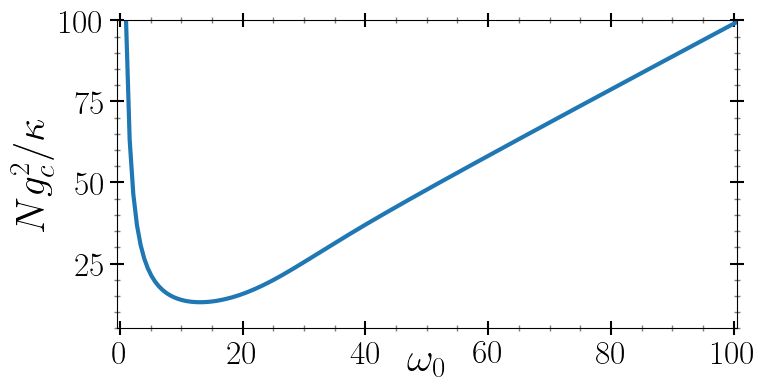

In [8]:
fig, ax = subplots(figsize=(8, 4))
ax.plot(omegauv, gc_values, lw=3) 
ax.minorticks_on()
ax.tick_params(which="both", direction="inout", 
                top=true, right=true, bottom=true, left=true)
ax.tick_params(axis="both", which="major", 
                length=10, width=1.5, colors="black")
ax.tick_params(axis="both", which="minor", 
                length=5, width=1, colors="gray")

ax.set_ylabel(L"Ng_c^2/\kappa")
ax.set_xlabel(L"\omega_0", labelpad=-20)
ax.set_ylim(5, 100)
ax.set_xlim(-0.5,100.5)
ax.grid(false)
show()
display(fig)

Check parameters below to determine threshold

In [10]:
Δ = -100
κ = 10
N = 1
δD = 10
ω0 = 15
fun(t) = exp(-δD^2 * t^2 / 2) * (sin(ω0 * t));
Int, _ = quadgk(fun, 0, Inf; order=9);

gc = sqrt(1/Int * ((κ*κ + Δ*Δ)/(-2*Δ*N)))

print("Critical coupling is gc=", gc)

Critical coupling is gc=25.91179149508538